In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Charger en chunks et ne garder que les films avec budget ET revenue > 0
chunks = pd.read_csv("../data/raw/TMDB_movie_dataset_v11.csv", chunksize=100000)
df = pd.concat([chunk[(chunk['budget'] > 0) & (chunk['revenue'] > 0)] for chunk in chunks])

print(f"Nombre de films après filtrage budget/revenue > 0 : {len(df)}")
print(f"Colonnes : {df.columns.tolist()}")
df.head()

Nombre de films après filtrage budget/revenue > 0 : 16530
Colonnes : ['id', 'title', 'vote_average', 'vote_count', 'status', 'release_date', 'revenue', 'runtime', 'adult', 'backdrop_path', 'budget', 'homepage', 'imdb_id', 'original_language', 'original_title', 'overview', 'popularity', 'poster_path', 'tagline', 'genres', 'production_companies', 'production_countries', 'spoken_languages', 'keywords']


,id,title,vote_average,vote_count,status,release_date,revenue,runtime,adult,backdrop_path,...,original_title,overview,popularity,poster_path,tagline,genres,production_companies,production_countries,spoken_languages,keywords
0,27205,Inception,8.364,34495,Released,2010-07-15,825532764,148,False,/8ZTVqvKDQ8emSGUEMjsS4yHAwrp.jpg,...,Inception,"Cobb, a skilled thief who commits corporate es...",83.952,/oYuLEt3zVCKq57qu2F8dT7NIa6f.jpg,Your mind is the scene of the crime.,"Action, Science Fiction, Adventure","Legendary Pictures, Syncopy, Warner Bros. Pict...","United Kingdom, United States of America","English, French, Japanese, Swahili","rescue, mission, dream, airplane, paris, franc..."
1,157336,Interstellar,8.417,32571,Released,2014-11-05,701729206,169,False,/pbrkL804c8yAv3zBZR4QPEafpAR.jpg,...,Interstellar,The adventures of a group of explorers who mak...,140.241,/gEU2QniE6E77NI6lCU6MxlNBvIx.jpg,Mankind was born on Earth. It was never meant ...,"Adventure, Drama, Science Fiction","Legendary Pictures, Syncopy, Lynda Obst Produc...","United Kingdom, United States of America",English,"rescue, future, spacecraft, race against time,..."
2,155,The Dark Knight,8.512,30619,Released,2008-07-16,1004558444,152,False,/nMKdUUepR0i5zn0y1T4CsSB5chy.jpg,...,The Dark Knight,Batman raises the stakes in his war on crime. ...,130.643,/qJ2tW6WMUDux911r6m7haRef0WH.jpg,Welcome to a world without rules.,"Drama, Action, Crime, Thriller","DC Comics, Legendary Pictures, Syncopy, Isobel...","United Kingdom, United States of America","English, Mandarin","joker, sadism, chaos, secret identity, crime f..."
3,19995,Avatar,7.573,29815,Released,2009-12-15,2923706026,162,False,/vL5LR6WdxWPjLPFRLe133jXWsh5.jpg,...,Avatar,"In the 22nd century, a paraplegic Marine is di...",79.932,/kyeqWdyUXW608qlYkRqosgbbJyK.jpg,Enter the world of Pandora.,"Action, Adventure, Fantasy, Science Fiction","Dune Entertainment, Lightstorm Entertainment, ...","United States of America, United Kingdom","English, Spanish","future, society, culture clash, space travel, ..."
4,24428,The Avengers,7.710,29166,Released,2012-04-25,1518815515,143,False,/9BBTo63ANSmhC4e6r62OJFuK2GL.jpg,...,The Avengers,When an unexpected enemy emerges and threatens...,98.082,/RYMX2wcKCBAr24UyPD7xwmjaTn.jpg,Some assembly required.,"Science Fiction, Action, Adventure",Marvel Studios,United States of America,"English, Hindi, Russian","new york city, superhero, shield, based on com..."


(16530, 24)
id                        int64
title                    object
vote_average            float64
vote_count                int64
status                   object
release_date             object
revenue                   int64
runtime                   int64
adult                      bool
backdrop_path            object
budget                    int64
homepage                 object
imdb_id                  object
original_language        object
original_title           object
overview                 object
popularity              float64
poster_path              object
tagline                  object
genres                   object
production_companies     object
production_countries     object
spoken_languages         object
keywords                 object
dtype: object
id                          0
title                       0
vote_average                0
vote_count                  0
status                      0
release_date             2940
revenue                   

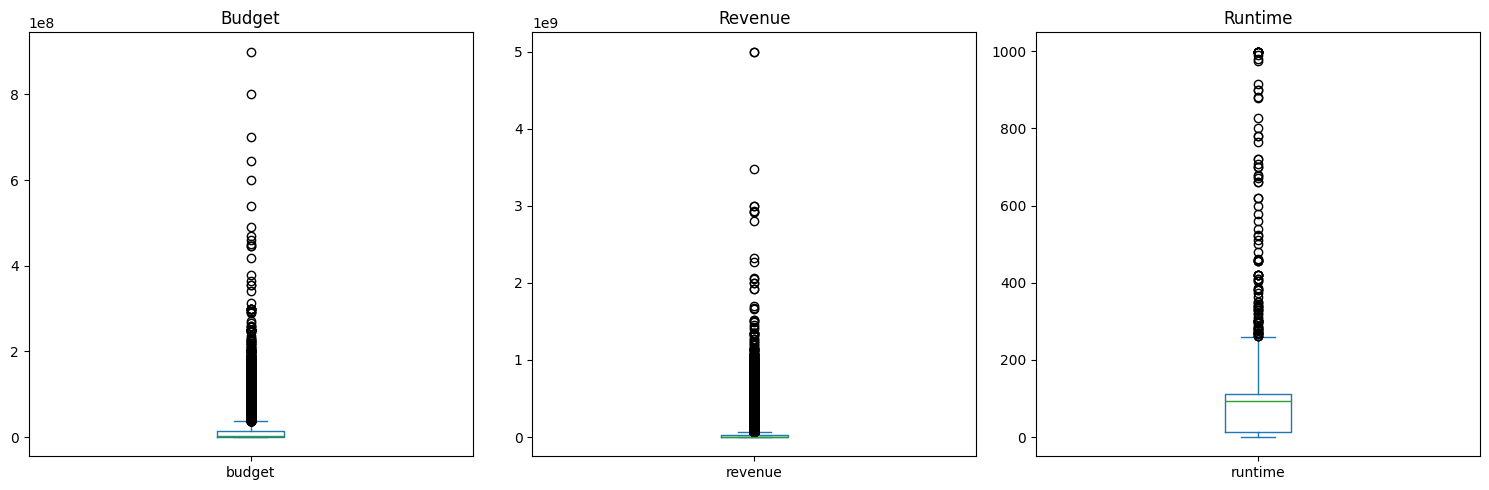

In [15]:
# Infos générales
print(df.shape)
print(df.dtypes)
print(df.isnull().sum())
print(df.describe())

# Boxplots
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
df['budget'].plot(kind='box', ax=axes[0], title='Budget')
df['revenue'].plot(kind='box', ax=axes[1], title='Revenue')
df['runtime'].plot(kind='box', ax=axes[2], title='Runtime')
plt.tight_layout()
plt.savefig("../outputs/figures/boxplots_exploration.png", dpi=300)
plt.show()

In [16]:
# Colonnes à GARDER (pré-sortie uniquement)
colonnes_features = [
    'title',
    'keywords',
    'overview',
    'genres',            # vérifie le nom exact dans ton CSV
    'adult',
    'budget',
    'runtime',
    'release_date',
    'original_language',
    'production_countries',
    'production_companies'
]

# Revenue : gardé TEMPORAIREMENT pour créer la cible, puis supprimé
colonnes_a_garder = colonnes_features + ['revenue']

# Vérifier que les colonnes existent
for col in colonnes_a_garder:
    if col in df.columns:
        print(f"✅ {col}")
    else:
        print(f"❌ {col} — INTROUVABLE, vérifie le nom exact")

df = df[colonnes_a_garder]

✅ title
✅ keywords
✅ overview
✅ genres
✅ adult
✅ budget
✅ runtime
✅ release_date
✅ original_language
✅ production_countries
✅ production_companies
✅ revenue


In [17]:
# Supprimer les lignes avec > 50% de valeurs manquantes
seuil = len(df.columns) * 0.5
df = df.dropna(thresh=seuil)
print(f"Après suppression lignes >50% NaN : {len(df)} films")

# Supprimer les doublons éventuels
df = df.drop_duplicates()
print(f"Après suppression doublons : {len(df)} films")

Après suppression lignes >50% NaN : 16530 films
Après suppression doublons : 16520 films


In [18]:
# Avant imputation : voir combien de NaN
print("=== Avant imputation ===")
print(df.isnull().sum())
print(f"\nTotal NaN : {df.isnull().sum().sum()}")

# Runtime : médiane
df['runtime'] = df['runtime'].fillna(df['runtime'].median())

# Texte : chaîne vide
for col in ['title', 'keywords', 'overview']:
    df[col] = df[col].fillna('')

# Catégories : 'unknown'
for col in ['genres', 'original_language', 'production_countries', 'production_companies']:
    df[col] = df[col].fillna('unknown')

# Adult : remplir par False si manquant
df['adult'] = df['adult'].fillna(False)

# Après imputation : vérification
print("\n=== Après imputation ===")
print(df.isnull().sum())
print(f"\nTotal NaN : {df.isnull().sum().sum()}")

=== Avant imputation ===
title                      0
keywords                5363
overview                2262
genres                  2782
adult                      0
budget                     0
runtime                    0
release_date            2931
original_language          0
production_countries    4359
production_companies    4355
revenue                    0
dtype: int64

Total NaN : 22052

=== Après imputation ===
title                      0
keywords                   0
overview                   0
genres                     0
adult                      0
budget                     0
runtime                    0
release_date            2931
original_language          0
production_countries       0
production_companies       0
revenue                    0
dtype: int64

Total NaN : 2931


In [19]:
# Calculer le ROI (formule standard - cohérent avec notebook 01)
df['ROI'] = (df['revenue'] - df['budget']) / df['budget']

# Statistiques détaillées du ROI
print("=== Statistiques du ROI ===")
print(df['ROI'].describe())
print(f"\nROI min : {df['ROI'].min():.2f}")
print(f"ROI max : {df['ROI'].max():.2f}")
print(f"ROI médian : {df['ROI'].median():.2f}")
print(f"ROI à 99% : {df['ROI'].quantile(0.99):.2f}")
print(f"ROI à 95% : {df['ROI'].quantile(0.95):.2f}")
print(f"ROI à 90% : {df['ROI'].quantile(0.90):.2f}")

# Combien de films ont un ROI négatif (perte) ?
print(f"\nFilms avec ROI < 0 (perte) : {(df['ROI'] < 0).sum()} ({(df['ROI'] < 0).sum() / len(df) * 100:.1f}%)")
print(f"Films avec ROI entre 0-1 : {((df['ROI'] >= 0) & (df['ROI'] <= 1)).sum()}")
print(f"Films avec ROI > 5 : {(df['ROI'] > 5).sum()}")


=== Statistiques du ROI ===


count    1.652000e+04
mean     6.258677e+05
std      4.149388e+07
min     -1.000000e+00
25%     -3.023084e-01
50%      4.704687e-01
75%      2.690052e+00
max      5.000000e+09
Name: ROI, dtype: float64

ROI min : -1.00
ROI max : 4999999998.00
ROI médian : 0.47
ROI à 99% : 1185.98
ROI à 95% : 24.23
ROI à 90% : 9.00

Films avec ROI < 0 (perte) : 4985 (30.2%)
Films avec ROI entre 0-1 : 4931
Films avec ROI > 5 : 2670


In [20]:
# ==========================================
# SUPPRESSION DES OUTLIERS EXTRÊMES DU ROI
# ==========================================

# Investiguer les films avec ROI extrême
print("=== Top 10 films avec ROI le plus élevé ===")
outliers = df[df['ROI'] > 100][['title', 'budget', 'revenue', 'ROI']].sort_values('ROI', ascending=False)
print(outliers.head(10))
print(f"\nNombre total de films avec ROI > 100 : {len(outliers)}")

# Supprimer les outliers extrêmes (garder seulement ROI <= percentile 99%)
seuil_roi_max = df['ROI'].quantile(0.99)
print(f"\n=== Suppression des outliers ===")
print(f"Seuil ROI max (99e percentile) : {seuil_roi_max:.2f}")
print(f"Nombre de films avant : {len(df)}")

df = df[df['ROI'] <= seuil_roi_max]

print(f"Nombre de films après : {len(df)}")
print(f"Films supprimés : {16520 - len(df)}")

# Nouvelles statistiques après nettoyage
print("\n=== Statistiques du ROI après nettoyage ===")
print(df['ROI'].describe())
print(f"\nROI min : {df['ROI'].min():.2f}")
print(f"ROI max : {df['ROI'].max():.2f}")
print(f"ROI médian : {df['ROI'].median():.2f}")

=== Top 10 films avec ROI le plus élevé ===
                                                    title  budget     revenue  \
638018  Juliet and Romeo - 1231 ☆*: .｡. o(≧▽≦)o .｡.:*☆...       1  4999999999   
435156                                 ירידתם של המגניבים       1  1000000000   
726123                   GEESE - THE MONEY TALKS TOUR '24       1  1000000000   
503538                              Pouring Out The Heart       1  1000000000   
306796                                      Lil Detective       2   999999999   
435396                                    חברים על סמים 2       5  1000000000   
435464                                    חברים על סמים 1       5  1000000000   
435168                                               דילן       5  1000000000   
278556                                 Żyraf: Czas Zemsty       1   100004215   
484009                            The Read N Review Movie       2   200000000   

                 ROI  
638018  5.000000e+09  
435156  1.000000e+

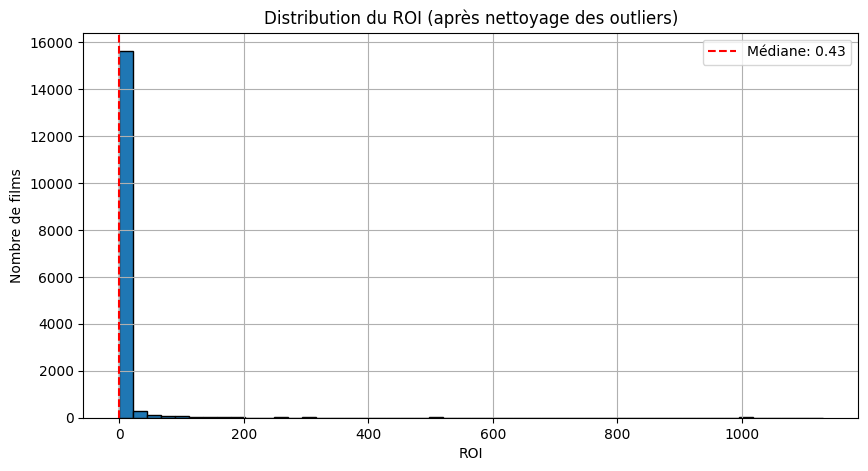


=== Distribution des classes ===
rentabilite
0    3271
1    3538
2    3107
3    3168
4    3270
Name: count, dtype: int64

rentabilite
0    20.0
1    21.6
2    19.0
3    19.4
4    20.0
Name: proportion, dtype: float64% par classe


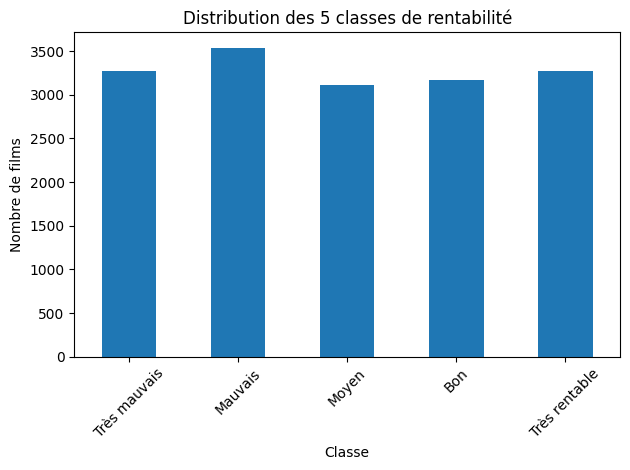

In [21]:
# ==========================================
# VISUALISATION ET CRÉATION DES CLASSES (après nettoyage)
# ==========================================

# Visualiser la distribution du ROI (après nettoyage des outliers)
plt.figure(figsize=(10, 5))
df['ROI'].hist(bins=50, edgecolor='black')
plt.title('Distribution du ROI (après nettoyage des outliers)')
plt.xlabel('ROI')
plt.ylabel('Nombre de films')
plt.axvline(df['ROI'].median(), color='r', linestyle='--', label=f'Médiane: {df["ROI"].median():.2f}')
plt.legend()
plt.savefig("../outputs/figures/distribution_roi_clean.png", dpi=300)
plt.show()

# Créer 5 classes par quantiles (classes équilibrées ~20% chacune)
df['rentabilite'] = pd.qcut(df['ROI'], q=5, labels=[0, 1, 2, 3, 4])

print("\n=== Distribution des classes ===")
print(df['rentabilite'].value_counts().sort_index())
print(f"\n{(df['rentabilite'].value_counts(normalize=True).sort_index() * 100).round(1)}% par classe")

# Barplot
df['rentabilite'].value_counts().sort_index().plot(kind='bar')
plt.title('Distribution des 5 classes de rentabilité')
plt.xlabel('Classe')
plt.ylabel('Nombre de films')
plt.xticks(range(5), ['Très mauvais', 'Mauvais', 'Moyen', 'Bon', 'Très rentable'], rotation=45)
plt.tight_layout()
plt.savefig("../outputs/figures/distribution_classes.png", dpi=300)
plt.show()

In [22]:
# Supprimer revenue et ROI (on garde seulement la classe de rentabilité)
df = df.drop(columns=['revenue', 'ROI'])

print(f"✅ Colonnes supprimées : revenue, ROI")
print(f"Colonnes restantes : {df.columns.tolist()}")
print(f"Shape finale : {df.shape}")

✅ Colonnes supprimées : revenue, ROI
Colonnes restantes : ['title', 'keywords', 'overview', 'genres', 'adult', 'budget', 'runtime', 'release_date', 'original_language', 'production_countries', 'production_companies', 'rentabilite']
Shape finale : (16354, 12)


In [23]:
# Option A : Extraire l'année depuis release_date
df['release_year'] = pd.to_datetime(df['release_date'], errors='coerce').dt.year

# Imputer les années manquantes avec la médiane
df['release_year'] = df['release_year'].fillna(df['release_year'].median())

# Supprimer la colonne release_date originale
df = df.drop(columns=['release_date'])

print(f"✅ Année extraite depuis release_date")
print(f"Années min/max : {df['release_year'].min():.0f} - {df['release_year'].max():.0f}")


✅ Année extraite depuis release_date
Années min/max : 1898 - 2085


In [24]:
# Vérifier qu'il n'y a plus de NaN
print("\n=== Vérification finale ===")
print(f"Valeurs manquantes :\n{df.isnull().sum()}")
print(f"\nTotal NaN : {df.isnull().sum().sum()}")

# Afficher les infos finales
print(f"\n=== Dataset final ===")
print(f"Nombre de films : {len(df)}")
print(f"Nombre de features : {len(df.columns) - 1}")  # -1 pour exclure la cible
print(f"Colonnes : {df.columns.tolist()}")

# Afficher un aperçu
print("\n=== Aperçu des données finales ===")
print(df.head())
print(f"\nDistribution de la cible :\n{df['rentabilite'].value_counts().sort_index()}")



=== Vérification finale ===
Valeurs manquantes :
title                   0
keywords                0
overview                0
genres                  0
adult                   0
budget                  0
runtime                 0
original_language       0
production_countries    0
production_companies    0
rentabilite             0
release_year            0
dtype: int64

Total NaN : 0

=== Dataset final ===
Nombre de films : 16354
Nombre de features : 11
Colonnes : ['title', 'keywords', 'overview', 'genres', 'adult', 'budget', 'runtime', 'original_language', 'production_countries', 'production_companies', 'rentabilite', 'release_year']

=== Aperçu des données finales ===
             title                                           keywords  \
0        Inception  rescue, mission, dream, airplane, paris, franc...   
1     Interstellar  rescue, future, spacecraft, race against time,...   
2  The Dark Knight  joker, sadism, chaos, secret identity, crime f...   
3           Avatar  future

In [25]:
# Sauvegarder en CSV
output_path = '../data/processed/movies_cleaned2.csv'
df.to_csv(output_path, index=False)
print(f"\n✅ Dataset nettoyé sauvegardé : {output_path}")
print(f"Taille : {len(df)} lignes × {len(df.columns)} colonnes")


✅ Dataset nettoyé sauvegardé : ../data/processed/movies_cleaned2.csv
Taille : 16354 lignes × 12 colonnes
